## Import Library

In [1]:
#pytorch lib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms,models
from torch.utils.data import Dataset,random_split
import torch.optim as optim


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os,shutil,warnings
import glob
import random 
import rasterio
import json

from tqdm import tqdm
from PIL import Image
from IPython.display import display
from torchvision import transforms
from typing import Tuple, Dict, List

from sklearn.metrics import precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

# If seed is needed 
# random.seed(69)

## Loading Sample Image

In [2]:
import rasterio
from rasterio.enums import ColorInterp

with rasterio.open('./datasets/WaveDetection/Masked/S1A_20150108T104104_440D.tif') as src:
    print(src.colorinterp)

(<ColorInterp.red: 3>, <ColorInterp.green: 4>, <ColorInterp.blue: 5>, <ColorInterp.alpha: 6>)


File: ./datasets/WaveDetection/Masked/S1A_20150108T104104_440D.tif
Width: 2896
Height: 2496
Number of bands: 4
CRS: EPSG:32750
Transform: | 100.00, 0.00, 191570.93|
| 0.00,-100.00, 9212248.66|
| 0.00, 0.00, 1.00|
Max: 0
Min: 0
Average: 0.0
Standard Deviation: 0.0


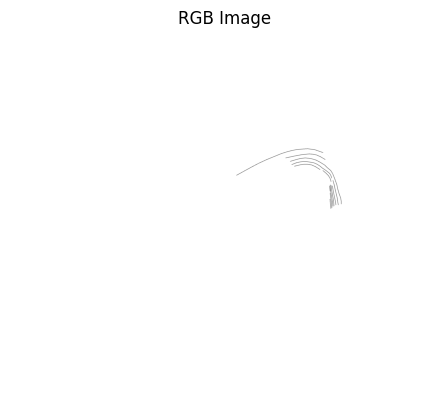

In [3]:
#View tif image using rasterio 
tiff_img = './datasets/WaveDetection/Masked/S1A_20150108T104104_440D.tif'
with rasterio.open(tiff_img) as dataset:
    #dataset 
    print(f"File: {tiff_img}")
    print(f"Width: {dataset.width}")
    print(f"Height: {dataset.height}")
    print(f"Number of bands: {dataset.count}")
    print(f"CRS: {dataset.crs}")
    print(f"Transform: {dataset.transform}")

    # Uncomment the below infos if you want to view infos in all bands
    # for band in range(1, dataset.count + 1):
    #     # Read the band data
    #     band_data = dataset.read(band)


    # Read the bands individually (assuming band order: red, green, blue, alpha)
    red = dataset.read(1)
    green = dataset.read(2)
    blue = dataset.read(3)
    alpha = dataset.read(4)

    # Stack the bands along the third dimension to create a (height, width, 4) array
    rgba = np.dstack([red, green, blue, alpha])
    
    data = dataset.read(1)
    
    maximum = np.max(data)
    minimum = np.min(data)
    average = np.mean(data)
    std = np.std(data)
    
    print("Max:", maximum)
    print("Min:", minimum)
    print("Average:", average)
    print("Standard Deviation:", std)


    
    def normalize(array):
        array_min, array_max = array.min(), array.max()
        return (array - array_min) / (array_max - array_min)

    #you can uncomment this to test what happened if not normalized properly
    # red = normalize(red_band)
    # green = normalize(green_band)
    # blue = normalize(blue_band)

    # Stack the bands to create an RGB image
    #rgb = np.dstack((red, green, blue))

    # Display the RGB image
    plt.imshow(rgba)
    plt.title('RGB Image')
    plt.axis('off')  # Hide the ax
    plt.show()


In [4]:
image = rasterio.open('./datasets/WaveDetection/Datasets/S1A_20150108T104104_440D.tif')
data = image.read(1)

maximum = np.max(data)
minimum = np.min(data)
average = np.mean(data)
std = np.std(data)

print("Max:", maximum)
print("Min:", minimum)
print("Average:", average)
print("Standard Deviation:", std)

Max: 11.448801
Min: -51.89792
Average: -6.815207
Standard Deviation: 6.9779024


# U-Net Implementation

In [5]:


# class DoubleConv(nn.Module):
#     """Two consecutive convolution layers with BatchNorm and ReLU activation."""
#     def __init__(self, in_channels, out_channels):
#         super(DoubleConv, self).__init__()
#         self.double_conv = nn.Sequential(
#             nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
#             nn.BatchNorm2d(out_channels),
#             nn.ReLU(inplace=True),
#             nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
#             nn.BatchNorm2d(out_channels),
#             nn.ReLU(inplace=True),
#         )

#     def forward(self, x):
#         return self.double_conv(x)

# class Down(nn.Module):
#     """Downscaling with maxpool then double conv."""
#     def __init__(self, in_channels, out_channels):
#         super(Down, self).__init__()
#         self.maxpool_conv = nn.Sequential(
#             nn.MaxPool2d(2),
#             DoubleConv(in_channels, out_channels)
#         )

#     def forward(self, x):
#         return self.maxpool_conv(x)

# class Up(nn.Module):
#     """Upscaling then double conv. Uses bilinear upsampling by default."""
#     def __init__(self, in_channels, out_channels, bilinear=True):
#         super(Up, self).__init__()

#         # if bilinear, use the normal upsampling and then a conv to reduce channels.
#         if bilinear:
#             self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
#             self.conv = DoubleConv(in_channels, out_channels)
#         else:
#             # Otherwise, use transposed convolution.
#             self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)
#             self.conv = DoubleConv(in_channels, out_channels)

#     def forward(self, x1, x2):
#         x1 = self.up(x1)
#         # Compute differences in size to pad if necessary.
#         diffY = x2.size()[2] - x1.size()[2]
#         diffX = x2.size()[3] - x1.size()[3]
#         x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
#                         diffY // 2, diffY - diffY // 2])
#         # Concatenate along the channels axis.
#         x = torch.cat([x2, x1], dim=1)
#         return self.conv(x)

# class OutConv(nn.Module):
#     """Final 1x1 convolution layer to map to the desired number of classes."""
#     def __init__(self, in_channels, out_channels):
#         super(OutConv, self).__init__()
#         self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

#     def forward(self, x):
#         return self.conv(x)

# # U-Net Model

# class UNet(nn.Module):
#     def __init__(self, n_channels, n_classes, bilinear=True):
#         """
#         Args:
#             n_channels (int): Number of channels in the input image (e.g., 4 for a 4-band GeoTIFF).
#             n_classes (int): Number of output channels/classes (e.g., 1 for binary segmentation).
#             bilinear (bool): Whether to use bilinear upsampling.
#         """
#         super(UNet, self).__init__()
#         self.n_channels = n_channels
#         self.n_classes = n_classes
#         self.bilinear = bilinear

#         self.inc = DoubleConv(n_channels, 64)
#         self.down1 = Down(64, 128)
#         self.down2 = Down(128, 256)
#         self.down3 = Down(256, 512)
#         factor = 2 if bilinear else 1
#         self.down4 = Down(512, 1024 // factor)
#         self.up1 = Up(1024, 512 // factor, bilinear)
#         self.up2 = Up(512, 256 // factor, bilinear)
#         self.up3 = Up(256, 128 // factor, bilinear)
#         self.up4 = Up(128, 64, bilinear)
#         self.outc = OutConv(64, n_classes)

#     def forward(self, x):
#         x1 = self.inc(x)   # First conv block
#         x2 = self.down1(x1)  # Downsample 1
#         x3 = self.down2(x2)  # Downsample 2
#         x4 = self.down3(x3)  # Downsample 3
#         x5 = self.down4(x4)  # Bottleneck
#         x = self.up1(x5, x4)  # Upsample + concat with x4
#         x = self.up2(x, x3)   # Upsample + concat with x3
#         x = self.up3(x, x2)   # Upsample + concat with x2
#         x = self.up4(x, x1)   # Upsample + concat with x1
#         logits = self.outc(x)
#         return logits


## Datasets Class Initialization (GeoTIFF to Tensor, No normalization)

In [6]:
class GeoTiffDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, normalize=None, 
                 mask_channels='all', target_size=None):
        """
        Args:
            image_dir (str): Directory with GeoTIFF images (grayscale, 1 channel).
            mask_dir (str): Directory with corresponding RGBA mask files.
            transform (callable, optional): A function/transform that takes a dict 
                {'image': image, 'mask': mask} and returns a transformed version.
            normalize (callable, optional): A normalization transform for the image.
            mask_channels (str): 'all' to return the full 4-channel mask, or 'alpha'
                to use only the alpha channel.
            target_size (tuple, optional): (target_H, target_W). If provided, every sample
                is padded to this size. Otherwise, the maximum height and width among all
                images and masks is computed and used.
        """
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_filenames = sorted(os.listdir(image_dir))
        self.mask_filenames = sorted(os.listdir(mask_dir))
        self.transform = transform
        self.normalize = normalize
        self.mask_channels = mask_channels

        if len(self.image_filenames) != len(self.mask_filenames):
            raise ValueError("The number of images does not match the number of masks.")
        
        # Determine the global target size.
        if target_size is not None:
            self.target_shape = target_size
        else:
            max_h, max_w = 0, 0
            # Scan through images.
            for fname in self.image_filenames:
                path = os.path.join(self.image_dir, fname)
                with rasterio.open(path) as src:
                    h, w = src.height, src.width
                    max_h = max(max_h, h)
                    max_w = max(max_w, w)
            # Scan through masks.
            for fname in self.mask_filenames:
                path = os.path.join(self.mask_dir, fname)
                with rasterio.open(path) as src:
                    h, w = src.height, src.width
                    max_h = max(max_h, h)
                    max_w = max(max_w, w)
            self.target_shape = (max_h, max_w)
        print(f"Global target shape for padding: {self.target_shape}")

    def pad_to_shape(self, arr, target_shape):
        """
        Pads a numpy array with zeros so that its spatial dimensions (H, W) equal target_shape.
        It pads on the bottom and right sides.
        
        Args:
            arr (np.ndarray): Array with shape (C, H, W) for images or (H, W) for 2D masks.
            target_shape (tuple): Desired (target_H, target_W).
        Returns:
            np.ndarray: Padded array with spatial dimensions = target_shape.
        """
        if arr.ndim == 3:
            # For image: shape (C, H, W)
            C, H, W = arr.shape
            pad_h = target_shape[0] - H
            pad_w = target_shape[1] - W
            pad_h = pad_h if pad_h > 0 else 0
            pad_w = pad_w if pad_w > 0 else 0
            padded = np.pad(arr, ((0, 0), (0, pad_h), (0, pad_w)), mode='constant', constant_values=0)
        elif arr.ndim == 2:
            # For mask: shape (H, W)
            H, W = arr.shape
            pad_h = target_shape[0] - H
            pad_w = target_shape[1] - W
            pad_h = pad_h if pad_h > 0 else 0
            pad_w = pad_w if pad_w > 0 else 0
            padded = np.pad(arr, ((0, pad_h), (0, pad_w)), mode='constant', constant_values=0)
        else:
            raise ValueError("Array must be 2D or 3D.")
        return padded

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        # Build full file paths.
        image_path = os.path.join(self.image_dir, self.image_filenames[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_filenames[idx])
        
        # Load the grayscale image (expected shape: [1, H, W]).
        with rasterio.open(image_path) as src:
            image = src.read().astype(np.float32)
        
        # Load the mask (expected shape: [4, H, W] for RGBA).
        with rasterio.open(mask_path) as src:
            mask = src.read().astype(np.float32)
            if self.mask_channels == 'alpha':
                # Use only the alpha channel (resulting in shape [H, W]).
                mask = mask[3]
        
        # Pad both image and mask to the global target shape.
        image = self.pad_to_shape(image, self.target_shape)
        mask = self.pad_to_shape(mask, self.target_shape)
        
        # Apply optional transforms.
        if self.transform:
            sample = self.transform(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
        
        # Convert arrays to torch tensors.
        image = torch.from_numpy(image)
        mask = torch.from_numpy(mask) if isinstance(mask, np.ndarray) else mask

        # Optionally apply normalization to the image.
        if self.normalize:
            image = self.normalize(image)
        
        return image, mask


## Init Dataloder 

In [7]:
image_directory = "./datasets/WaveDetection/Datasets/"
mask_directory = "./datasets/WaveDetection/PNG Osawa/PNG/"

# if transform is neededzz
# transform = transforms.Compose([
#     RANDOM TRANSFORM GOES HERE (don't need to call toTensor since from_numpy is already called
# ])

# in case normalized is needed? idk about GeoTiff much
#normalize = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    

dataset = GeoTiffDataset(image_directory, mask_directory, transform=None, normalize=None,target_size=[1000,2000])
print("Dataset size:", len(dataset))

# Retrieve a sample
sample_image, sample_mask = dataset[121]
print("Image tensor shape:", sample_image.shape)
print("Mask tensor shape:", sample_mask.shape)

train_size = int(0.2 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])


dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)
#val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)



Global target shape for padding: [1000, 2000]
Dataset size: 255
Image tensor shape: torch.Size([1, 2455, 2890])
Mask tensor shape: torch.Size([4, 2455, 2890])


/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [8]:
train_dataset.dataset[0][0].shape


torch.Size([1, 2496, 2896])

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=4):
        super(UNet, self).__init__()
        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.pool = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        # Decoder
        self.upconv = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(64 + 64, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.out_conv = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        x1 = self.enc1(x)       # [B, 64, H, W]
        x2 = self.pool(x1)      # [B, 64, H/2, W/2]
        x3 = self.enc2(x2)      # [B, 128, H/2, W/2]
        x4 = self.upconv(x3)    # [B, 64, ? , ?]
        # Crop x1 to match x4's spatial dimensions if needed
        diffY = x1.size()[2] - x4.size()[2]
        diffX = x1.size()[3] - x4.size()[3]
        if diffY != 0 or diffX != 0:
            x1 = x1[:, :, :x4.size()[2], :x4.size()[3]]
        x_cat = torch.cat([x1, x4], dim=1)  # [B, 128, H, W]
        x5 = self.dec1(x_cat)   # [B, 64, H, W]
        return self.out_conv(x5)  # [B, out_channels, H, W]

# # Minimal test:
# if __name__ == "__main__":
#     model = UNet(in_channels=1, out_channels=4)
#     x = torch.randn(1, 1, 2865, 2917)  # Example input (could be any size)
#     y = model(x)
#     print("Output shape:", y.shape)


In [10]:

# Instantiate the U-Net model.
# Input is 1-channel (grayscale), and output should be 4 channels (one per class).
#model = UNet(n_channels=1, n_classes=4, bilinear=True)
model = UNet()
# Set device to GPU if available.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Number of training epochs.


num_epochs = 1
learning_rate = 1e-3
batch_size = 1


criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop.
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, masks in dataloader:
        images = images.to(device)  # [B, 1, H, W]
        masks = masks.to(device)    # [B, 4, H, W]
        
        optimizer.zero_grad()
        outputs = model(images)     # [B, 4, H, W]

        if outputs.shape[2:] != masks.shape[2:]:
            outputs = F.interpolate(outputs, size=masks.shape[2:], mode='bilinear', align_corners=False)

        
        # Compute the loss directly between multi-channel output and mask.
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
    
    epoch_loss = running_loss / len(dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}")

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/conv.py:952: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv_transpose2d(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with an OutOfMemoryError: CUDA out of memory. Tried to allocate 4.01 GiB. GPU  (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:924.)
  return F.conv2d(input, weight, bias, self.stride,
/usr/local

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 GiB. GPU 